<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/21_NeuroFHIR_TRACE_Downstream_Model_A_B_C_Utility_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 21
## Downstream Model A vs B vs C Utility Experiment


**Project:** NeuroFHIR-TRACE — Provenance-Aware Reliability Gating for Longitudinal Neuroimaging AI

---

## Scientific question

Does controlling the quality of patient-level AI-derived neuroimaging evidence improve downstream behavior compared with blindly propagating all imaging features?

This notebook implements the primary downstream experiment specified in the TRACE blueprint.

### Model A — Clinical baseline
Non-imaging clinical predictors only.

### Model B — Raw imaging AI
Clinical predictors + all AI-derived imaging features, without TRACE filtering or weighting.

### Model C1 — Trusted-only TRACE
Clinical predictors + imaging evidence only when TRACE classifies it as TRUSTED.

### Model C2 — Reliability-weighted TRACE
Clinical predictors + imaging evidence attenuated by the continuous TRACE reliability score.

### Model C3 — Full TRACE gate
Clinical predictors + gated imaging evidence + TRACE state/risk metadata.

---

## Primary comparisons

1. **A vs B on clean data**  
   Does AI-derived imaging add predictive information?

2. **B clean vs B shifted**  
   Does raw imaging AI become fragile under technical shift?

3. **B vs C under shift**  
   Does TRACE reduce the propagation of unstable evidence?

4. **C1 vs C2 vs C3**  
   Which reliability-aware strategy works best?

---

## Outcomes

- AUROC
- AUPRC
- Brier score
- calibration error
- ranking stability under shift
- top-risk-set consistency
- false progression / false high-risk events
- paired subject-level bootstrap confidence intervals

### Important

A successful TRACE result does **not** require a higher AUROC.

A strong result can instead be:

- better calibration;
- lower Brier score;
- lower degradation under shift;
- more stable patient ranking;
- lower false-progression rate;
- fewer confidently wrong predictions.

If no real MCI/AD clinical table is connected, the notebook enters **DEMO_MODE** and produces pipeline-validation results only.


In [1]:

# ============================================================
# 0. SETUP
# ============================================================

!pip -q install pandas numpy scipy scikit-learn pyarrow matplotlib

from pathlib import Path
import json, random, warnings, math
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kendalltau

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")
IN20B = ROOT / "outputs_20B"
OUT_DIR = ROOT / "outputs_21"
FIG_DIR = OUT_DIR / "figures"

for p in [OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

N_BOOT = 500

print("Input:", IN20B)
print("Output:", OUT_DIR)


Input: /content/neurofhir_trace/outputs_20B
Output: /content/neurofhir_trace/outputs_21



# 1. Input contract

For the **real ICHI run**, prepare one subject-level table containing:

```text
subject_id
split                       # development / heldout
outcome                     # e.g., MCI->AD progression
age
sex
baseline_cognitive_score
other_clinical_predictors...
imaging_clean               # clean AI-derived imaging biomarker
imaging_shifted             # same evidence under technical/site/model shift
trace_risk                  # 0-1 predicted instability
trace_reliability_score     # 1 - trace_risk
trace_state                 # TRUSTED / CAUTION / REVIEW_REQUIRED
false_change_event          # optional
```

The current notebook supports a self-contained DEMO path when this table is unavailable.

For the final manuscript, replace the demo outcome and predictors with the real downstream MCI/AD progression dataset.


In [2]:

# ============================================================
# 1. LOAD 20B OUTPUT IF AVAILABLE
# ============================================================

candidate_trace_paths = [
    IN20B / "heldout_three_state_trace_predictions.csv",
    Path("/content/heldout_three_state_trace_predictions.csv"),
]

trace_path = next((p for p in candidate_trace_paths if p.exists()), None)

candidate_gate_paths = [
    IN20B / "frozen_trace_three_state_gate.json",
    Path("/content/frozen_trace_three_state_gate.json"),
]

gate_path = next((p for p in candidate_gate_paths if p.exists()), None)

print("TRACE prediction file:", trace_path)
print("Gate file:", gate_path)


TRACE prediction file: None
Gate file: None



# 2. Real-data path vs DEMO_MODE

If a complete downstream subject table is not available, this notebook generates an independent demonstration cohort.

The demonstration is designed so that:

- clinical predictors carry real signal;
- clean imaging carries additional signal;
- technical shift contaminates raw imaging;
- TRACE risk correlates with technical contamination, not directly with the outcome;
- TRACE-aware handling can therefore improve robustness without being given the target label directly.

This preserves the intended causal story better than simply making TRACE a proxy for the outcome.


In [3]:

# ============================================================
# 2. SEARCH FOR REAL DOWNSTREAM TABLE
# ============================================================

candidate_downstream_paths = [
    ROOT / "inputs" / "trace_downstream_subject_table.parquet",
    ROOT / "inputs" / "trace_downstream_subject_table.csv",
    Path("/content/trace_downstream_subject_table.parquet"),
    Path("/content/trace_downstream_subject_table.csv"),
]

downstream_path = next((p for p in candidate_downstream_paths if p.exists()), None)

if downstream_path is not None:
    DEMO_MODE = False

    if downstream_path.suffix == ".parquet":
        df = pd.read_parquet(downstream_path)
    else:
        df = pd.read_csv(downstream_path)

    print("Loaded real downstream table:", downstream_path)

else:
    DEMO_MODE = True
    print("No downstream subject table found.")
    print("Creating self-contained DEMO dataset.")
    print("IMPORTANT: Results are pipeline validation only.")


No downstream subject table found.
Creating self-contained DEMO dataset.
IMPORTANT: Results are pipeline validation only.


In [4]:

# ============================================================
# 2B. SELF-CONTAINED DEMO DATASET
# ============================================================

if DEMO_MODE:
    rng = np.random.default_rng(SEED)

    n_subjects = 520
    subject_ids = [f"MCI{i:04d}" for i in range(1, n_subjects+1)]

    # Fixed subject split.
    shuffled = subject_ids.copy()
    rng.shuffle(shuffled)
    n_dev = int(0.70*n_subjects)
    dev_ids = set(shuffled[:n_dev])

    rows = []

    for sid in subject_ids:
        split = "development" if sid in dev_ids else "heldout"

        # -------------------------
        # Clinical baseline factors
        # -------------------------
        age = np.clip(rng.normal(72, 7), 55, 90)
        sex = rng.binomial(1, 0.48)
        cognitive = np.clip(rng.normal(26, 2.3), 18, 30)
        apoe4 = rng.binomial(1, 0.34)
        functional = np.clip(rng.normal(0.45, 0.25), 0, 1.5)

        # -------------------------
        # Latent biological imaging signal
        # -------------------------
        true_hippocampal_z = rng.normal(
            loc=(
                -0.03*(age-72)
                -0.18*apoe4
                +0.10*(cognitive-26)
            ),
            scale=0.75
        )

        # -------------------------
        # Outcome generation
        # Imaging contributes independently beyond clinical variables.
        # -------------------------
        linear_outcome = (
            -0.8
            +0.045*(age-72)
            +0.70*apoe4
            -0.42*(cognitive-26)
            +0.55*functional
            -0.80*true_hippocampal_z
        )

        outcome_prob = 1/(1+np.exp(-linear_outcome))
        outcome = rng.binomial(1, outcome_prob)

        # -------------------------
        # Technical instability is generated independently
        # of the downstream outcome.
        # -------------------------
        instability = rng.binomial(1, 0.30)

        trace_risk = np.clip(
            rng.normal(
                0.14 + 0.62*instability,
                0.13
            ),
            0,
            1
        )

        trace_reliability = 1-trace_risk

        if trace_risk <= 0.25:
            trace_state = "TRUSTED"
        elif trace_risk >= 0.65:
            trace_state = "REVIEW_REQUIRED"
        else:
            trace_state = "CAUTION"

        # -------------------------
        # Imaging measurements
        # -------------------------
        imaging_clean = (
            true_hippocampal_z
            + rng.normal(0, 0.12)
        )

        # Shift error is much larger in unstable evidence.
        shift_error = rng.normal(
            0,
            0.18 + 1.00*instability
        )

        # occasional sign-changing systematic artifact
        if instability and rng.random() < 0.30:
            shift_error += rng.choice([-1,1])*rng.uniform(0.8,1.8)

        imaging_shifted = imaging_clean + shift_error

        # "False progression" event = technical shift large enough
        # to imply a clinically meaningful imaging change.
        false_change_event = int(
            abs(imaging_shifted-imaging_clean) > 0.75
        )

        rows.append({
            "subject_id": sid,
            "split": split,
            "outcome": outcome,
            "age": age,
            "sex": sex,
            "baseline_cognitive_score": cognitive,
            "apoe4": apoe4,
            "functional_score": functional,
            "imaging_clean": imaging_clean,
            "imaging_shifted": imaging_shifted,
            "trace_risk": trace_risk,
            "trace_reliability_score": trace_reliability,
            "trace_state": trace_state,
            "false_change_event": false_change_event,
            "latent_instability_demo_only": instability
        })

    df = pd.DataFrame(rows)

    print("Created DEMO dataset")
    print("Rows:", len(df))
    print("Outcome prevalence:", round(df.outcome.mean(),3))
    print(df.trace_state.value_counts(normalize=True).round(3))


Created DEMO dataset
Rows: 520
Outcome prevalence: 0.437
trace_state
TRUSTED            0.594
REVIEW_REQUIRED    0.240
CAUTION            0.165
Name: proportion, dtype: float64



# 3. Validate schema

The notebook uses a compact clinical baseline:

- age
- sex
- baseline cognitive score
- APOE4 indicator
- functional score

Replace these with the real clinical predictors available in the final MCI progression dataset.


In [5]:

# ============================================================
# 3. SCHEMA
# ============================================================

CLINICAL_FEATURES = [
    "age",
    "sex",
    "baseline_cognitive_score",
    "apoe4",
    "functional_score"
]

required = [
    "subject_id",
    "split",
    "outcome",
    "imaging_clean",
    "imaging_shifted",
    "trace_risk",
    "trace_reliability_score",
    "trace_state"
] + CLINICAL_FEATURES

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.copy()
df["outcome"] = df["outcome"].astype(int)

dev = df[df.split=="development"].copy()
held = df[df.split=="heldout"].copy()

print("Development subjects:", dev.subject_id.nunique())
print("Held-out subjects:", held.subject_id.nunique())
print("Development outcome prevalence:", round(dev.outcome.mean(),3))
print("Held-out outcome prevalence:", round(held.outcome.mean(),3))
print("DEMO_MODE =", DEMO_MODE)


Development subjects: 364
Held-out subjects: 156
Development outcome prevalence: 0.448
Held-out outcome prevalence: 0.41
DEMO_MODE = True



# 4. Construct Model A/B/C inputs

### A — Clinical baseline
Clinical variables only.

### B — Raw imaging AI
Clinical variables + raw imaging biomarker.

### C1 — Trusted-only
Use imaging only for TRUSTED evidence.  
CAUTION / REVIEW_REQUIRED imaging is replaced by the development median and an explicit missing/rejected indicator.

### C2 — Reliability-weighted
Multiply the imaging feature by the continuous TRACE reliability score.

### C3 — Full TRACE gate
Clinical variables + gated imaging + TRACE risk + state indicators.

Importantly, the same downstream outcome model family is used across comparisons.


In [6]:

# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

DEV_IMAGING_MEDIAN = float(
    dev["imaging_clean"].median()
)

def build_condition_table(source_df, imaging_column):
    x = source_df.copy()

    # Model B raw imaging.
    x["B_imaging"] = x[imaging_column]

    # C1 trusted-only.
    trusted = x["trace_state"].eq("TRUSTED")
    x["C1_imaging"] = np.where(
        trusted,
        x[imaging_column],
        DEV_IMAGING_MEDIAN
    )
    x["C1_imaging_rejected"] = (~trusted).astype(int)

    # C2 reliability-weighted.
    # Center around development median before attenuation.
    centered = (
        x[imaging_column]-DEV_IMAGING_MEDIAN
    )
    x["C2_imaging"] = (
        DEV_IMAGING_MEDIAN
        + centered*x["trace_reliability_score"]
    )

    # C3 full gate:
    # trusted = full evidence
    # caution = attenuated evidence
    # review = neutralized evidence
    state_weight = np.select(
        [
            x.trace_state.eq("TRUSTED"),
            x.trace_state.eq("CAUTION"),
            x.trace_state.eq("REVIEW_REQUIRED")
        ],
        [
            1.0,
            x["trace_reliability_score"],
            0.0
        ],
        default=0.0
    )

    x["C3_imaging"] = (
        DEV_IMAGING_MEDIAN
        + centered*state_weight
    )

    x["C3_trace_risk"] = x["trace_risk"]
    x["C3_state_caution"] = (
        x.trace_state=="CAUTION"
    ).astype(int)
    x["C3_state_review"] = (
        x.trace_state=="REVIEW_REQUIRED"
    ).astype(int)

    return x


dev_clean = build_condition_table(
    dev,
    "imaging_clean"
)

held_clean = build_condition_table(
    held,
    "imaging_clean"
)

held_shifted = build_condition_table(
    held,
    "imaging_shifted"
)



# 5. Model definitions

All models use:

- median imputation;
- standardization;
- logistic regression.

This keeps the comparison interpretable and prevents the downstream result from being driven by a more powerful model class in one arm.


In [7]:

# ============================================================
# 5. MODEL FEATURE SETS
# ============================================================

MODEL_FEATURES = {
    "A_clinical": CLINICAL_FEATURES,

    "B_raw_imaging": (
        CLINICAL_FEATURES
        + ["B_imaging"]
    ),

    "C1_trusted_only": (
        CLINICAL_FEATURES
        + [
            "C1_imaging",
            "C1_imaging_rejected"
        ]
    ),

    "C2_reliability_weighted": (
        CLINICAL_FEATURES
        + ["C2_imaging"]
    ),

    "C3_full_TRACE": (
        CLINICAL_FEATURES
        + [
            "C3_imaging",
            "C3_trace_risk",
            "C3_state_caution",
            "C3_state_review"
        ]
    )
}

MODEL_FEATURES


{'A_clinical': ['age',
  'sex',
  'baseline_cognitive_score',
  'apoe4',
  'functional_score'],
 'B_raw_imaging': ['age',
  'sex',
  'baseline_cognitive_score',
  'apoe4',
  'functional_score',
  'B_imaging'],
 'C1_trusted_only': ['age',
  'sex',
  'baseline_cognitive_score',
  'apoe4',
  'functional_score',
  'C1_imaging',
  'C1_imaging_rejected'],
 'C2_reliability_weighted': ['age',
  'sex',
  'baseline_cognitive_score',
  'apoe4',
  'functional_score',
  'C2_imaging'],
 'C3_full_TRACE': ['age',
  'sex',
  'baseline_cognitive_score',
  'apoe4',
  'functional_score',
  'C3_imaging',
  'C3_trace_risk',
  'C3_state_caution',
  'C3_state_review']}

In [8]:

# ============================================================
# 5B. FIT ON DEVELOPMENT CLEAN DATA ONLY
# ============================================================

models = {}

for name, feats in MODEL_FEATURES.items():

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            solver="liblinear",
            max_iter=1000,
            random_state=SEED
        ))
    ])

    pipe.fit(
        dev_clean[feats],
        dev_clean["outcome"]
    )

    models[name] = pipe

print("Fitted:", list(models))


Fitted: ['A_clinical', 'B_raw_imaging', 'C1_trusted_only', 'C2_reliability_weighted', 'C3_full_TRACE']



# 6. Generate clean and shifted held-out predictions

The downstream models are **not retrained** under shift.

That is essential: the experiment asks whether evidence handling changes robustness when technical conditions change.


In [9]:

# ============================================================
# 6. PREDICTIONS
# ============================================================

pred = pd.DataFrame({
    "subject_id": held["subject_id"].values,
    "outcome": held["outcome"].values,
    "trace_state": held["trace_state"].values,
    "trace_risk": held["trace_risk"].values
})

if "false_change_event" in held.columns:
    pred["false_change_event"] = held[
        "false_change_event"
    ].values

for name, feats in MODEL_FEATURES.items():

    pred[f"{name}_clean"] = (
        models[name]
        .predict_proba(
            held_clean[feats]
        )[:,1]
    )

    pred[f"{name}_shifted"] = (
        models[name]
        .predict_proba(
            held_shifted[feats]
        )[:,1]
    )

display(pred.head())


,subject_id,outcome,trace_state,trace_risk,false_change_event,A_clinical_clean,A_clinical_shifted,B_raw_imaging_clean,B_raw_imaging_shifted,C1_trusted_only_clean,C1_trusted_only_shifted,C2_reliability_weighted_clean,C2_reliability_weighted_shifted,C3_full_TRACE_clean,C3_full_TRACE_shifted
0,MCI0002,1,CAUTION,0.442595,0,0.084235,0.084235,0.045002,0.059728,0.099879,0.099879,0.057600,0.070153,0.081890,0.096485
1,MCI0006,1,CAUTION,0.312599,0,0.921327,0.921327,0.939327,0.926756,0.924326,0.924326,0.934920,0.923396,0.947117,0.939080
2,MCI0007,1,CAUTION,0.580316,0,0.743652,0.743652,0.800770,0.733656,0.750760,0.750760,0.779669,0.743292,0.848294,0.824881
3,MCI0011,0,TRUSTED,0.220492,0,0.124863,0.124863,0.123774,0.107576,0.114993,0.100769,0.119258,0.103788,0.119925,0.102971
4,MCI0014,1,TRUSTED,0.069346,0,0.692393,0.692393,0.759239,0.747191,0.756098,0.744770,0.775672,0.762116,0.756323,0.743171



# 7. Evaluation functions


In [10]:

# ============================================================
# 7. METRIC FUNCTIONS
# ============================================================

def expected_calibration_error(
    y,
    p,
    n_bins=10
):
    y = np.asarray(y)
    p = np.asarray(p)

    bins = np.linspace(
        0,
        1,
        n_bins+1
    )

    ids = np.digitize(
        p,
        bins[1:-1],
        right=True
    )

    ece = 0.0

    for b in range(n_bins):
        m = ids==b

        if not np.any(m):
            continue

        ece += (
            np.mean(m)
            * abs(
                np.mean(y[m])
                -np.mean(p[m])
            )
        )

    return float(ece)


def classification_metrics(
    y,
    p
):
    y = np.asarray(y)
    p = np.asarray(p)

    return {
        "AUROC": (
            roc_auc_score(y,p)
            if len(np.unique(y))==2
            else np.nan
        ),
        "AUPRC": (
            average_precision_score(y,p)
            if len(np.unique(y))==2
            else np.nan
        ),
        "Brier": brier_score_loss(y,p),
        "ECE_10bin": expected_calibration_error(
            y,p,10
        )
    }


def ranking_stability(
    clean_p,
    shifted_p,
    top_fraction=0.20
):
    clean_p = np.asarray(clean_p)
    shifted_p = np.asarray(shifted_p)

    spearman = spearmanr(
        clean_p,
        shifted_p
    ).statistic

    kendall = kendalltau(
        clean_p,
        shifted_p
    ).statistic

    n_top = max(
        1,
        int(
            round(
                len(clean_p)*top_fraction
            )
        )
    )

    clean_top = set(
        np.argsort(clean_p)[-n_top:]
    )

    shifted_top = set(
        np.argsort(shifted_p)[-n_top:]
    )

    top_consistency = (
        len(
            clean_top.intersection(
                shifted_top
            )
        )
        / n_top
    )

    return {
        "Spearman_clean_vs_shift": spearman,
        "Kendall_clean_vs_shift": kendall,
        "Top20pct_consistency": top_consistency
    }



# 8. Primary A/B/C results

For each model report:

- clean performance;
- shifted performance;
- degradation due to shift;
- ranking stability.


In [11]:

# ============================================================
# 8. PRIMARY RESULTS
# ============================================================

y = pred["outcome"].values

rows = []

for name in MODEL_FEATURES:

    p_clean = pred[
        f"{name}_clean"
    ].values

    p_shift = pred[
        f"{name}_shifted"
    ].values

    clean_m = classification_metrics(
        y,
        p_clean
    )

    shift_m = classification_metrics(
        y,
        p_shift
    )

    rank_m = ranking_stability(
        p_clean,
        p_shift
    )

    row = {
        "model": name,
        **{
            f"clean_{k}":v
            for k,v in clean_m.items()
        },
        **{
            f"shifted_{k}":v
            for k,v in shift_m.items()
        },
        **rank_m
    }

    row["AUROC_degradation"] = (
        clean_m["AUROC"]
        -shift_m["AUROC"]
    )

    row["Brier_worsening"] = (
        shift_m["Brier"]
        -clean_m["Brier"]
    )

    row["ECE_worsening"] = (
        shift_m["ECE_10bin"]
        -clean_m["ECE_10bin"]
    )

    rows.append(row)

results = pd.DataFrame(rows)

display(
    results[
        [
            "model",
            "clean_AUROC",
            "shifted_AUROC",
            "AUROC_degradation",
            "clean_Brier",
            "shifted_Brier",
            "Brier_worsening",
            "clean_ECE_10bin",
            "shifted_ECE_10bin",
            "Spearman_clean_vs_shift",
            "Top20pct_consistency"
        ]
    ].sort_values(
        "shifted_Brier"
    )
)


,model,clean_AUROC,shifted_AUROC,AUROC_degradation,clean_Brier,shifted_Brier,Brier_worsening,clean_ECE_10bin,shifted_ECE_10bin,Spearman_clean_vs_shift,Top20pct_consistency
3,C2_reliability_weighted,0.760530,0.754755,0.005774,0.202492,0.204686,0.002194,0.132140,0.124025,0.987293,0.838710
4,C3_full_TRACE,0.753906,0.750170,0.003736,0.206252,0.207316,0.001064,0.137398,0.144416,0.995183,0.935484
2,C1_trusted_only,0.747283,0.745245,0.002038,0.208456,0.208692,0.000237,0.128428,0.112839,0.996905,0.935484
1,B_raw_imaging,0.760870,0.728601,0.032269,0.202048,0.218089,0.016041,0.123360,0.121891,0.923880,0.806452
0,A_clinical,0.709069,0.709069,0.000000,0.222772,0.222772,0.000000,0.107801,0.107801,1.000000,1.000000



# 9. Core causal comparisons

### Question 1
Does imaging add value on clean data?

**A vs B clean**

### Question 2
Does raw imaging become fragile under shift?

**B clean vs B shifted**

### Question 3
Does TRACE improve behavior under shift?

**B shifted vs C1/C2/C3 shifted**


In [12]:

# ============================================================
# 9. CORE COMPARISON TABLE
# ============================================================

r = results.set_index("model")

comparison_rows = []

# A vs B clean
comparison_rows.append({
    "comparison": "A vs B on clean data",
    "delta_AUROC": (
        r.loc["B_raw_imaging","clean_AUROC"]
        -r.loc["A_clinical","clean_AUROC"]
    ),
    "delta_Brier": (
        r.loc["B_raw_imaging","clean_Brier"]
        -r.loc["A_clinical","clean_Brier"]
    ),
    "interpretation": "Incremental value/fragility introduced by raw imaging AI"
})

# B clean vs shifted
comparison_rows.append({
    "comparison": "B clean vs B shifted",
    "delta_AUROC": (
        r.loc["B_raw_imaging","shifted_AUROC"]
        -r.loc["B_raw_imaging","clean_AUROC"]
    ),
    "delta_Brier": (
        r.loc["B_raw_imaging","shifted_Brier"]
        -r.loc["B_raw_imaging","clean_Brier"]
    ),
    "interpretation": "Technical-shift degradation of raw imaging AI"
})

for c in [
    "C1_trusted_only",
    "C2_reliability_weighted",
    "C3_full_TRACE"
]:
    comparison_rows.append({
        "comparison": f"{c} vs B under shift",
        "delta_AUROC": (
            r.loc[c,"shifted_AUROC"]
            -r.loc["B_raw_imaging","shifted_AUROC"]
        ),
        "delta_Brier": (
            r.loc[c,"shifted_Brier"]
            -r.loc["B_raw_imaging","shifted_Brier"]
        ),
        "interpretation": "TRACE utility relative to blindly propagated raw imaging"
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

display(comparison_df)


,comparison,delta_AUROC,delta_Brier,interpretation
0,A vs B on clean data,0.051800,-0.020725,Incremental value/fragility introduced by raw ...
1,B clean vs B shifted,-0.032269,0.016041,Technical-shift degradation of raw imaging AI
2,C1_trusted_only vs B under shift,0.016644,-0.009397,TRACE utility relative to blindly propagated r...
3,C2_reliability_weighted vs B under shift,0.026155,-0.013404,TRACE utility relative to blindly propagated r...
4,C3_full_TRACE vs B under shift,0.021569,-0.010773,TRACE utility relative to blindly propagated r...



# 10. Prediction-shift magnitude

A robust model should not change its patient-level risk estimate dramatically just because the imaging evidence experienced a technical perturbation.


In [13]:

# ============================================================
# 10. PREDICTION SHIFT
# ============================================================

shift_rows = []

for name in MODEL_FEATURES:

    clean_p = pred[
        f"{name}_clean"
    ].values

    shifted_p = pred[
        f"{name}_shifted"
    ].values

    delta = np.abs(
        shifted_p-clean_p
    )

    shift_rows.append({
        "model": name,
        "mean_abs_probability_shift": delta.mean(),
        "median_abs_probability_shift": np.median(delta),
        "p90_abs_probability_shift": np.quantile(delta,0.90),
        "max_abs_probability_shift": delta.max()
    })

prob_shift_df = pd.DataFrame(
    shift_rows
)

display(
    prob_shift_df.sort_values(
        "mean_abs_probability_shift"
    )
)


,model,mean_abs_probability_shift,median_abs_probability_shift,p90_abs_probability_shift,max_abs_probability_shift
0,A_clinical,0.000000,0.000000,0.000000,0.000000
2,C1_trusted_only,0.010969,0.003914,0.030303,0.094762
4,C3_full_TRACE,0.015500,0.008670,0.036996,0.108253
3,C2_reliability_weighted,0.027853,0.017370,0.069138,0.169868
1,B_raw_imaging,0.061118,0.019032,0.182495,0.579908



# 11. Confidently wrong predictions under shift

One of TRACE's strongest possible results is reducing high-confidence wrong predictions.

Here:

- positive confident error: predicted risk ≥ 0.80 when outcome = 0
- negative confident error: predicted risk ≤ 0.20 when outcome = 1


In [14]:

# ============================================================
# 11. CONFIDENTLY WRONG
# ============================================================

confident_rows = []

for name in MODEL_FEATURES:

    p = pred[
        f"{name}_shifted"
    ].values

    false_positive_confident = (
        (y==0) & (p>=0.80)
    )

    false_negative_confident = (
        (y==1) & (p<=0.20)
    )

    confident_wrong = (
        false_positive_confident
        | false_negative_confident
    )

    confident_rows.append({
        "model": name,
        "confidently_wrong_n": int(
            confident_wrong.sum()
        ),
        "confidently_wrong_rate": float(
            confident_wrong.mean()
        ),
        "confident_false_positive_n": int(
            false_positive_confident.sum()
        ),
        "confident_false_negative_n": int(
            false_negative_confident.sum()
        )
    })

confident_df = pd.DataFrame(
    confident_rows
)

display(
    confident_df.sort_values(
        "confidently_wrong_rate"
    )
)


,model,confidently_wrong_n,confidently_wrong_rate,confident_false_positive_n,confident_false_negative_n
3,C2_reliability_weighted,12,0.076923,3,9
4,C3_full_TRACE,12,0.076923,3,9
2,C1_trusted_only,14,0.089744,5,9
0,A_clinical,15,0.096154,6,9
1,B_raw_imaging,16,0.102564,8,8



# 12. False-progression / false-change consequence

When the dataset includes `false_change_event`, test whether technical imaging failures disproportionately perturb downstream risk in Model B, and whether TRACE reduces that propagation.

Endpoint:

**large downstream probability shift**, defined here as absolute clean→shift change ≥ 0.15.


In [15]:

# ============================================================
# 12. FALSE-CHANGE CONSEQUENCE
# ============================================================

false_change_analysis = pd.DataFrame()

if "false_change_event" in pred.columns:

    rows = []

    for name in MODEL_FEATURES:

        clean_p = pred[
            f"{name}_clean"
        ].values

        shift_p = pred[
            f"{name}_shifted"
        ].values

        prob_delta = np.abs(
            shift_p-clean_p
        )

        large_shift = (
            prob_delta >= 0.15
        )

        fc = pred[
            "false_change_event"
        ].values.astype(int)

        rows.append({
            "model": name,
            "large_prediction_shift_rate_all": float(
                large_shift.mean()
            ),
            "large_prediction_shift_rate_false_change": float(
                large_shift[fc==1].mean()
            ) if np.any(fc==1) else np.nan,
            "mean_probability_shift_false_change": float(
                prob_delta[fc==1].mean()
            ) if np.any(fc==1) else np.nan,
            "mean_probability_shift_no_false_change": float(
                prob_delta[fc==0].mean()
            ) if np.any(fc==0) else np.nan
        })

    false_change_analysis = pd.DataFrame(
        rows
    )

    display(
        false_change_analysis.sort_values(
            "large_prediction_shift_rate_false_change"
        )
    )

else:
    print("No false_change_event column available.")


,model,large_prediction_shift_rate_all,large_prediction_shift_rate_false_change,mean_probability_shift_false_change,mean_probability_shift_no_false_change
0,A_clinical,0.000000,0.000000,0.000000,0.000000
2,C1_trusted_only,0.000000,0.000000,0.000000,0.013368
4,C3_full_TRACE,0.000000,0.000000,0.003062,0.018221
3,C2_reliability_weighted,0.012821,0.071429,0.060360,0.020742
1,B_raw_imaging,0.134615,0.750000,0.235606,0.022949



# 13. Paired subject-level bootstrap

Because A/B/C predictions are evaluated on the **same held-out subjects**, comparisons should use paired resampling.

Primary bootstrap contrasts:

- B clean − A clean
- B shifted − B clean
- C1 shifted − B shifted
- C2 shifted − B shifted
- C3 shifted − B shifted

For Brier score, **negative delta is better**.


In [16]:

# ============================================================
# 13. PAIRED BOOTSTRAP
# ============================================================

def paired_bootstrap(
    pred_df,
    n_boot=500,
    seed=42
):
    rng = np.random.default_rng(seed)

    n = len(pred_df)
    rows = []

    for b in range(n_boot):

        idx = rng.choice(
            np.arange(n),
            size=n,
            replace=True
        )

        x = pred_df.iloc[idx].reset_index(drop=True)
        yb = x["outcome"].values

        if len(np.unique(yb)) < 2:
            continue

        row = {
            "bootstrap": b
        }

        # Store metrics.
        for name in MODEL_FEATURES:

            for condition in [
                "clean",
                "shifted"
            ]:

                p = x[
                    f"{name}_{condition}"
                ].values

                row[
                    f"{name}_{condition}_AUROC"
                ] = roc_auc_score(
                    yb,p
                )

                row[
                    f"{name}_{condition}_Brier"
                ] = brier_score_loss(
                    yb,p
                )

        # Primary contrasts.
        row["DELTA_AUROC_Bclean_minus_Aclean"] = (
            row["B_raw_imaging_clean_AUROC"]
            -row["A_clinical_clean_AUROC"]
        )

        row["DELTA_Brier_Bclean_minus_Aclean"] = (
            row["B_raw_imaging_clean_Brier"]
            -row["A_clinical_clean_Brier"]
        )

        row["DELTA_AUROC_Bshift_minus_Bclean"] = (
            row["B_raw_imaging_shifted_AUROC"]
            -row["B_raw_imaging_clean_AUROC"]
        )

        row["DELTA_Brier_Bshift_minus_Bclean"] = (
            row["B_raw_imaging_shifted_Brier"]
            -row["B_raw_imaging_clean_Brier"]
        )

        for c in [
            "C1_trusted_only",
            "C2_reliability_weighted",
            "C3_full_TRACE"
        ]:
            row[
                f"DELTA_AUROC_{c}_minus_Bshift"
            ] = (
                row[f"{c}_shifted_AUROC"]
                -row["B_raw_imaging_shifted_AUROC"]
            )

            row[
                f"DELTA_Brier_{c}_minus_Bshift"
            ] = (
                row[f"{c}_shifted_Brier"]
                -row["B_raw_imaging_shifted_Brier"]
            )

        rows.append(row)

    return pd.DataFrame(rows)


boot_df = paired_bootstrap(
    pred,
    n_boot=N_BOOT,
    seed=SEED
)

print(
    "Bootstrap replicates:",
    len(boot_df)
)


Bootstrap replicates: 500


In [17]:

# ============================================================
# 13B. BOOTSTRAP CI
# ============================================================

ci_rows = []

for col in boot_df.columns:

    if col=="bootstrap":
        continue

    if not col.startswith("DELTA"):
        continue

    s = boot_df[col].dropna()

    ci_rows.append({
        "metric": col,
        "mean": s.mean(),
        "median": s.median(),
        "ci_2.5": s.quantile(0.025),
        "ci_97.5": s.quantile(0.975)
    })

bootstrap_ci = pd.DataFrame(
    ci_rows
)

display(bootstrap_ci)


,metric,mean,median,ci_2.5,ci_97.5
0,DELTA_AUROC_Bclean_minus_Aclean,0.051540,0.051350,0.016774,0.085582
1,DELTA_Brier_Bclean_minus_Aclean,-0.020636,-0.020726,-0.035435,-0.005683
2,DELTA_AUROC_Bshift_minus_Bclean,-0.032117,-0.031874,-0.067374,0.001039
3,DELTA_Brier_Bshift_minus_Bclean,0.016155,0.016093,-0.000798,0.033260
4,DELTA_AUROC_C1_trusted_only_minus_Bshift,0.016939,0.016445,-0.018474,0.054961
5,DELTA_Brier_C1_trusted_only_minus_Bshift,-0.009545,-0.009349,-0.028566,0.007882
6,DELTA_AUROC_C2_reliability_weighted_minus_Bshift,0.026455,0.026827,-0.000692,0.056070
7,DELTA_Brier_C2_reliability_weighted_minus_Bshift,-0.013502,-0.013412,-0.028526,0.000431
8,DELTA_AUROC_C3_full_TRACE_minus_Bshift,0.022076,0.022141,-0.012249,0.058289
9,DELTA_Brier_C3_full_TRACE_minus_Bshift,-0.010936,-0.010679,-0.029117,0.005814



# 14. Figure — clean vs shifted Brier score

This figure is especially important if TRACE improves calibration/robustness without materially changing AUROC.


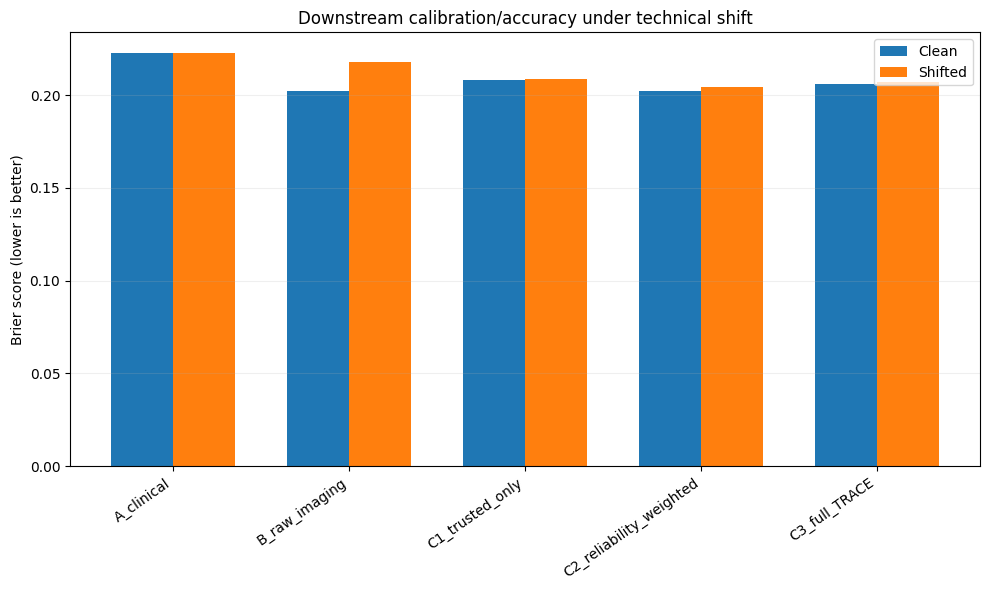

In [18]:

# ============================================================
# 14. BRIER FIGURE
# ============================================================

plot_df = results[
    [
        "model",
        "clean_Brier",
        "shifted_Brier"
    ]
].copy()

x = np.arange(
    len(plot_df)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(10,6)
)

ax.bar(
    x-width/2,
    plot_df["clean_Brier"],
    width,
    label="Clean"
)

ax.bar(
    x+width/2,
    plot_df["shifted_Brier"],
    width,
    label="Shifted"
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["model"],
    rotation=35,
    ha="right"
)

ax.set_ylabel("Brier score (lower is better)")
ax.set_title(
    "Downstream calibration/accuracy under technical shift"
)
ax.legend()
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"abc_brier_clean_vs_shifted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 15. Figure — ranking stability


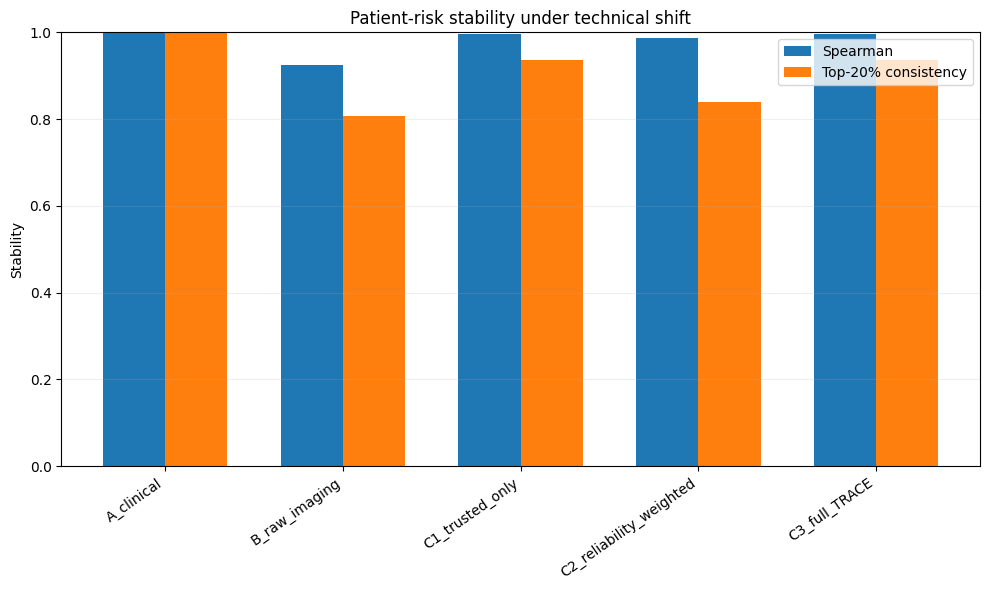

In [19]:

# ============================================================
# 15. RANKING STABILITY FIGURE
# ============================================================

rank_df = results[
    [
        "model",
        "Spearman_clean_vs_shift",
        "Top20pct_consistency"
    ]
].copy()

fig, ax = plt.subplots(
    figsize=(10,6)
)

x = np.arange(
    len(rank_df)
)

width = 0.35

ax.bar(
    x-width/2,
    rank_df["Spearman_clean_vs_shift"],
    width,
    label="Spearman"
)

ax.bar(
    x+width/2,
    rank_df["Top20pct_consistency"],
    width,
    label="Top-20% consistency"
)

ax.set_xticks(x)
ax.set_xticklabels(
    rank_df["model"],
    rotation=35,
    ha="right"
)

ax.set_ylim(0,1)
ax.set_ylabel("Stability")
ax.set_title(
    "Patient-risk stability under technical shift"
)
ax.legend()
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"abc_ranking_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 16. Figure — Model A/B/C shifted AUROC


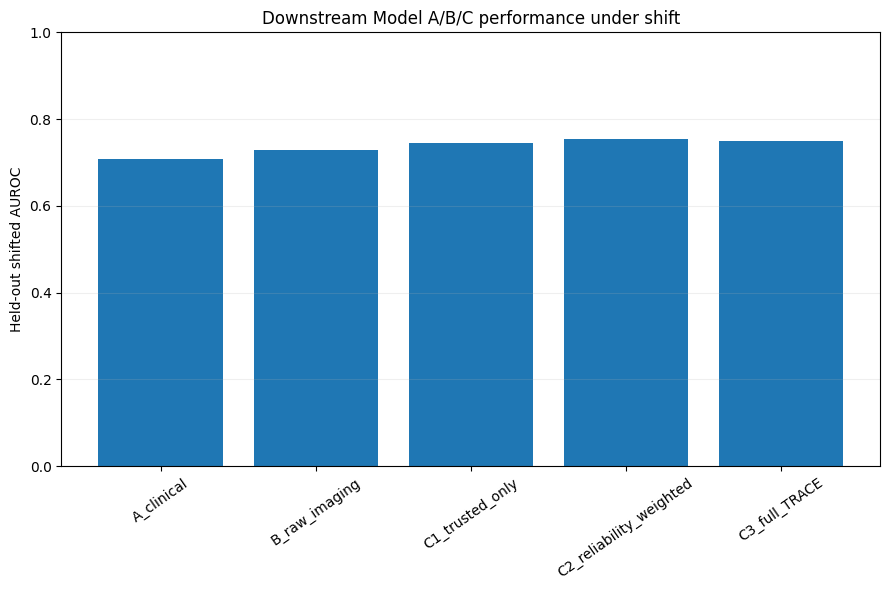

In [20]:

# ============================================================
# 16. SHIFTED AUROC
# ============================================================

fig, ax = plt.subplots(
    figsize=(9,6)
)

ax.bar(
    results["model"],
    results["shifted_AUROC"]
)

ax.set_ylim(0,1)
ax.set_ylabel("Held-out shifted AUROC")
ax.set_title(
    "Downstream Model A/B/C performance under shift"
)
ax.tick_params(
    axis="x",
    rotation=35
)
ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"abc_shifted_auroc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 17. Figure — raw B vs full TRACE patient-level probability shift


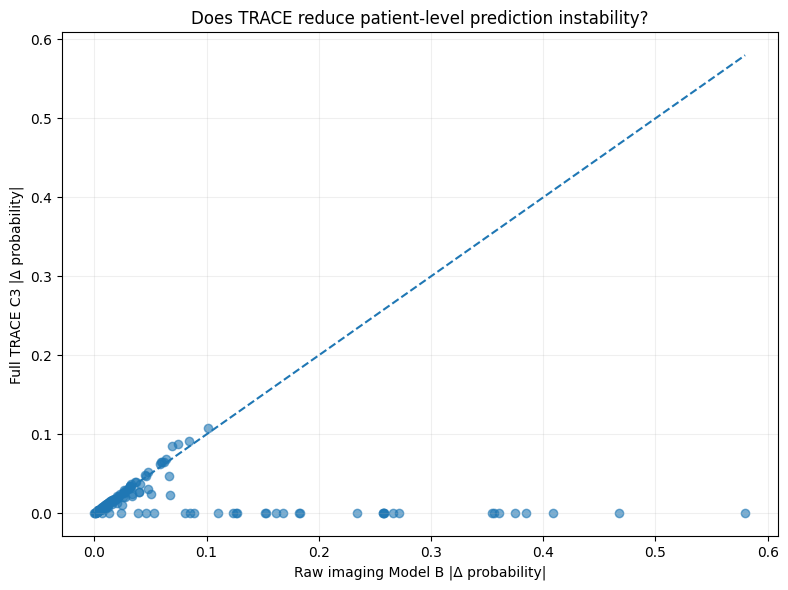

In [21]:

# ============================================================
# 17. PATIENT-LEVEL SHIFT
# ============================================================

b_delta = np.abs(
    pred["B_raw_imaging_shifted"]
    -pred["B_raw_imaging_clean"]
)

c3_delta = np.abs(
    pred["C3_full_TRACE_shifted"]
    -pred["C3_full_TRACE_clean"]
)

fig, ax = plt.subplots(
    figsize=(8,6)
)

ax.scatter(
    b_delta,
    c3_delta,
    alpha=0.6
)

limit = max(
    b_delta.max(),
    c3_delta.max()
)

ax.plot(
    [0,limit],
    [0,limit],
    linestyle="--"
)

ax.set_xlabel(
    "Raw imaging Model B |Δ probability|"
)
ax.set_ylabel(
    "Full TRACE C3 |Δ probability|"
)
ax.set_title(
    "Does TRACE reduce patient-level prediction instability?"
)
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIG_DIR/"patient_probability_shift_B_vs_C3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# 18. Export Notebook 21 artifacts


In [22]:

# ============================================================
# 18. EXPORT
# ============================================================

pred.to_csv(
    OUT_DIR/"heldout_abc_predictions.csv",
    index=False
)

results.to_csv(
    OUT_DIR/"abc_clean_shift_metrics.csv",
    index=False
)

comparison_df.to_csv(
    OUT_DIR/"abc_primary_comparisons.csv",
    index=False
)

prob_shift_df.to_csv(
    OUT_DIR/"abc_probability_shift.csv",
    index=False
)

confident_df.to_csv(
    OUT_DIR/"abc_confidently_wrong.csv",
    index=False
)

if len(false_change_analysis):
    false_change_analysis.to_csv(
        OUT_DIR/"abc_false_change_consequence.csv",
        index=False
    )

boot_df.to_parquet(
    OUT_DIR/"abc_paired_bootstrap.parquet",
    index=False
)

bootstrap_ci.to_csv(
    OUT_DIR/"abc_paired_bootstrap_ci.csv",
    index=False
)

print(
    "Saved Notebook 21 outputs to:",
    OUT_DIR
)


Saved Notebook 21 outputs to: /content/neurofhir_trace/outputs_21



# 19. ICHI-ready summary

The final paper should prioritize the following sequence:

### Q1 — Does imaging add value?
A vs B on clean data.

### Q2 — Does raw imaging AI degrade under shift?
B clean vs B shifted.

### Q3 — Does TRACE improve downstream behavior?
B shifted vs C1/C2/C3 shifted.

### Q4 — What does TRACE improve?
Prioritize:

1. calibration / Brier;
2. false-change control;
3. ranking stability;
4. confidently wrong predictions;
5. AUROC/AUPRC.

A higher AUROC is useful but not mandatory.


In [23]:

# ============================================================
# 19. SUMMARY
# ============================================================

r = results.set_index("model")

summary = {
    "DEMO_MODE": bool(DEMO_MODE),

    "N_development_subjects": int(
        dev.subject_id.nunique()
    ),

    "N_heldout_subjects": int(
        held.subject_id.nunique()
    ),

    "heldout_outcome_prevalence": float(
        held.outcome.mean()
    ),

    "A_clean_AUROC": float(
        r.loc[
            "A_clinical",
            "clean_AUROC"
        ]
    ),

    "B_clean_AUROC": float(
        r.loc[
            "B_raw_imaging",
            "clean_AUROC"
        ]
    ),

    "B_shifted_AUROC": float(
        r.loc[
            "B_raw_imaging",
            "shifted_AUROC"
        ]
    ),

    "B_shifted_Brier": float(
        r.loc[
            "B_raw_imaging",
            "shifted_Brier"
        ]
    ),

    "C1_shifted_Brier": float(
        r.loc[
            "C1_trusted_only",
            "shifted_Brier"
        ]
    ),

    "C2_shifted_Brier": float(
        r.loc[
            "C2_reliability_weighted",
            "shifted_Brier"
        ]
    ),

    "C3_shifted_Brier": float(
        r.loc[
            "C3_full_TRACE",
            "shifted_Brier"
        ]
    ),

    "B_ranking_Spearman": float(
        r.loc[
            "B_raw_imaging",
            "Spearman_clean_vs_shift"
        ]
    ),

    "C3_ranking_Spearman": float(
        r.loc[
            "C3_full_TRACE",
            "Spearman_clean_vs_shift"
        ]
    ),

    "B_top20_consistency": float(
        r.loc[
            "B_raw_imaging",
            "Top20pct_consistency"
        ]
    ),

    "C3_top20_consistency": float(
        r.loc[
            "C3_full_TRACE",
            "Top20pct_consistency"
        ]
    )
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["metric","value"]
)

display(summary_df)

summary_df.to_csv(
    OUT_DIR/"ichi_trace_21_summary.csv",
    index=False
)


,metric,value
0,DEMO_MODE,True
1,N_development_subjects,364
2,N_heldout_subjects,156
3,heldout_outcome_prevalence,0.410256
4,A_clean_AUROC,0.709069
5,B_clean_AUROC,0.76087
6,B_shifted_AUROC,0.728601
7,B_shifted_Brier,0.218089
8,C1_shifted_Brier,0.208692
9,C2_shifted_Brier,0.204686
